# Deep Learning


# 10.1 Single Layer Neural Network

A neural network is a non linear function f(X) which predicts the response Y for a given set of predictors or features X. 

The typical structure of a feed forward model contains a input layer, where the input features are feed in, a sequence of at least 1 hidden layer with K hidden units A1 ... An, and a output layer with one or more outputs Y. 

The output can be categorical e.g. in a classification task or a quantitave response e.g. in a regression task. With this structure the network models a function 

$$
f(X) = \beta_0 + \Sigma_{k=1}^K \beta_k h_k(X) \\
= \beta_0 + \Sigma_{k=1}^K \beta_k g(\omega_{k0} + \Sigma_{j=1}^p \omega_{kj} X_j)
$$

It is build up in two steps first we have the K activations in the hidden layer, which are computed as function of the input features

$$
A_k = h_k(X)=g(\omega_{k0} + \Sigma_{j=1}^p \omega_{kj} X_j)
$$

where g(X) is a non linear activation function. The non linear activation function can be seen as a non linear transformation of the input features into a different space, similar to kernel functions in the previous section.

These K activations from the hidden layer are then feed into an output layer, resulting in 

$$
f(X) = \beta_0 + \Sigma_{k=1}^K \beta_k A_k
$$

All parameters $\beta_0, ... \beta_k$ and the weights $\omega_0 ..., \omega_k $ need to be learned from data. 

The hidden layer constructs from the 4 input features 5 new features.

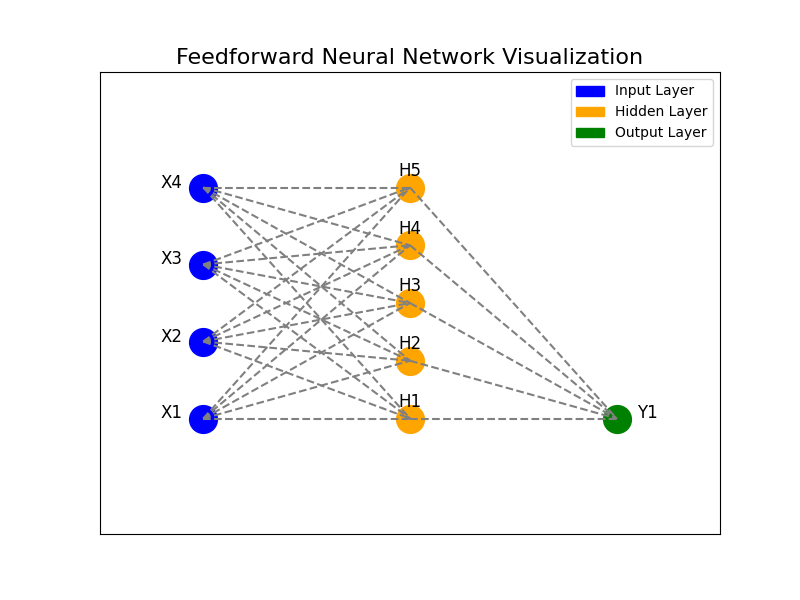

In [63]:
## Visualiyation of a feedforward neural network
## With X=4, H=5, Y=1 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
# Define the number of neurons in each layer
input_neurons = 4
hidden_neurons = 5
output_neurons = 1
# Define the positions of the neurons in each layer
input_layer_x = 0
hidden_layer_x = 1
output_layer_x = 2
input_layer_y = np.linspace(0, 1, input_neurons)
hidden_layer_y = np.linspace(0, 1, hidden_neurons)
output_layer_y = np.linspace(0, 1, output_neurons)
# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))
# Plot the neurons in the input layer
for i in range(input_neurons):
    ax.plot(input_layer_x, input_layer_y[i], 'o', color='blue', markersize=20)
    ax.text(input_layer_x - 0.1, input_layer_y[i], f'X{i+1}', fontsize=12, ha='right')
# Plot the neurons in the hidden layer
for i in range(hidden_neurons):
    ax.plot(hidden_layer_x, hidden_layer_y[i], 'o', color='orange', markersize=20)
    ax.text(hidden_layer_x, hidden_layer_y[i] + 0.05, f'H{i+1}', fontsize=12, ha='center')  
# Plot the neurons in the output layer
for i in range(output_neurons):
    ax.plot(output_layer_x, output_layer_y[i], 'o', color='green', markersize=20)
    ax.text(output_layer_x + 0.1, output_layer_y[i], f'Y{i+1}', fontsize=12, ha='left')
# Plot the connections between the layers
for i in range(input_neurons):
    for j in range(hidden_neurons):
        ax.plot([input_layer_x, hidden_layer_x], [input_layer_y[i], hidden_layer_y[j]], color='gray', linestyle='--')
for i in range(hidden_neurons):
    for j in range(output_neurons):
        ax.plot([hidden_layer_x, output_layer_x], [hidden_layer_y[i], output_layer_y[j]], color='gray', linestyle='--')
        
# Set the limits and labels
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(-0.5, 1.5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Feedforward Neural Network Visualization', fontsize=16)
# Add legend
input_patch = mpatches.Patch(color='blue', label='Input Layer')
hidden_patch = mpatches.Patch(color='orange', label='Hidden Layer')
output_patch = mpatches.Patch(color='green', label='Output Layer')
plt.legend(handles=[input_patch, hidden_patch, output_patch], loc='upper right')
# Show the plot
plt.show()

## Activation functions

The activation function is a non linear function which transforms the input into a non linear output. This functions make neural networks powerfull to model non linear relationships between the inputs and the outputs.

Typical activation functions are:

### Sigmoid

$$
g(z) = \frac{1}{1+e^-z}
$$

### ReLu (Rectivy linear unit)

$$
g(z) = 0 if z<0 else z
$$

### Tanh

g(z) = tanh(z)


Aside of this activation functions there exist several further activation functions like LeakyReLu and in general the activation function is a hyperparameter which can be optimized. Without the non linear activation the model would represent just a simple linear model.


## Interaction between parameters

As depicted in the image above the network connections allow interaction between the parameters. This is a analogy to the polynomial regression models for examples where we also had for example X1X2 as mixture term to represent interaction between the parameters.

## Fitting the model parameters

Within this model class we need need to learn the bias terms $\beta$ as well as the weights $\omega$. For a regression task as described in this model the squared error loss is used and the parameters need to be choosen to minimize it. 

$$
\Sigma_{i=1}^n (y_i - f(x_i))^2
$$

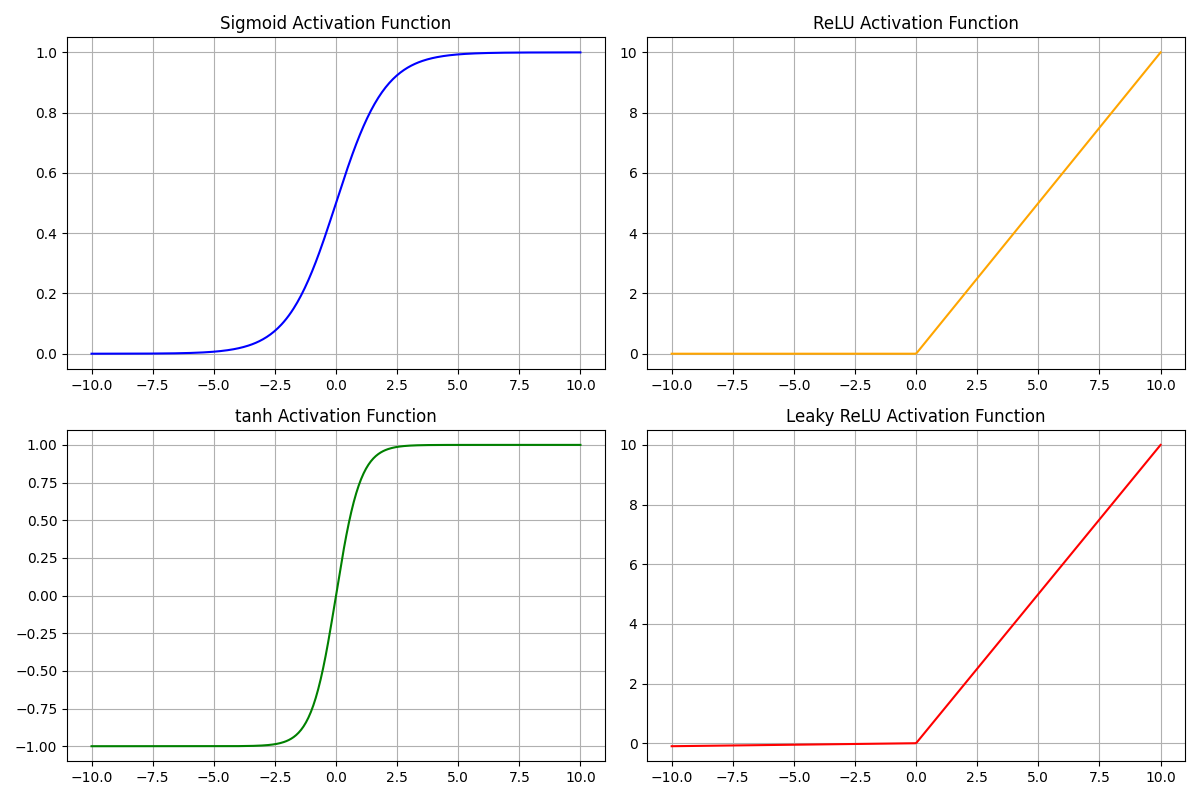

In [64]:
## lets visualize some activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def ReLu (x):
    return np.maximum(0, x)

def tanH(x):
    return np.tanh(x)

def LeakzyReLu(x):
    return np.where(x > 0, x, 0.01 * x)

x = np.linspace(-10, 10, 400)
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(x, sigmoid(x), label='Sigmoid', color='blue')
plt.title('Sigmoid Activation Function')
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(x, ReLu(x), label='ReLU', color='orange')
plt.title('ReLU Activation Function')
plt.grid()
plt.subplot(2, 2, 3)
plt.plot(x, tanH(x), label='tanh', color='green')
plt.title('tanh Activation Function')
plt.grid()
plt.subplot(2, 2, 4)
plt.plot(x, LeakzyReLu(x), label='Leaky ReLU', color='red')
plt.title('Leaky ReLU Activation Function')
plt.grid()
plt.tight_layout()
plt.show()

In [65]:
## lets build the simple feedforward neural network with random weights and biases using nuymPy

import numpy as np
# Define the number of neurons in each layer
input_neurons = 4
hidden_neurons = 5
output_neurons = 1
# Initialize random weights and biases (book notation)
omega_kj = np.random.rand(input_neurons, hidden_neurons)  # input->hidden weights (omega_kj)
omega_k0 = np.random.rand(hidden_neurons)  # hidden biases (omega_k0)
beta_k = np.random.rand(hidden_neurons, output_neurons)  # output weights (beta_k)
beta_0 = np.random.rand(output_neurons)  # output bias (beta_0)

# Now we need a sigmoid activation function to introduce non-linearity
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Define the feedforward function
def feedforward(X):
    # Calculate the hidden layer activations (uses omega_kj and omega_k0)
    hidden_layer_input = np.dot(X, omega_kj) + omega_k0  # omega_k0 + sum_j omega_kj * X_j
    hidden_layer_output = sigmoid(hidden_layer_input)  # A_k = g(...)

    # Calculate the output layer activations (uses beta_k and beta_0)
    output_layer_input = np.dot(hidden_layer_output, beta_k) + beta_0  # beta_0 + sum_k beta_k * A_k
    output_layer_output = sigmoid(output_layer_input)

    return output_layer_output

# Example input vector
X = np.random.rand(input_neurons)  # Random input vector of size 4
Y_target = np.random.rand(output_neurons)  # Random target output vector of size 1
# Get the output from the feedforward function
output = feedforward(X)
print("Input X:", X)
print("Target Y:", Y_target)
print("Output from feedforward:", output)

# Loss function L2 loss
def L2_loss(Y_target, Y_pred):
    return np.sum((Y_target - Y_pred) ** 2)

# Calculate the loss
loss = L2_loss(Y_target, output)
print("L2 Loss:", loss)

Input X: [0.32295647 0.79518619 0.27083225 0.43897142]
Target Y: [0.07845638]
Output from feedforward: [0.95321536]
L2 Loss: 0.765203268703827


## Fitting a neural network

The model we just created is missing an important piece, the capability to learn and updates its parameters from data. 

Recalling the model function 

$$
f(X) = \beta_0 + \Sigma_{k=1}^K \beta_k h_k(X) \\
= \beta_0 + \Sigma_{k=1}^K \beta_k g(\omega_{k0} + \Sigma_{j=1}^p \omega_{kj} X_j)
$$

and the minimization target (loss) function
$$
\Sigma_{i=1}^n (y_i - f(x_i))^2
$$

we essentially can fomulate a minimization problem

$$
min_{\omega_K|_1^K, \beta} \frac{1}{2} \Sigma_{i=1}^n (y_i - f(x_i))^2
$$

with the given forward function f(X). On a first glimps the objective looks simple enough but due to the symmetry in the hidden units (all inputs map to all hidden units) and the nested arrangment of the parameters $\beta and \omega$ the optimization is not straight forward and the optimizer can stuck in local minima, which means we wont find the global minima and thus the best parameter set to discriminate the data. The existence of local minima is linked to the non convex structure of the function.

In general two strategies are applied to reach the global minima (or approximate it as it cant be guaranteed that the global minima will be reached)

1. Slow Learning: Instead of trying to fit the full function in one step use a slow itterative fashion using gradient descent.
2. Regularization: Similar to the polynomial models, penalties are imposed to the model parameters e.g. lasso or ridge (See Notebook 6) to shrink the parameters and ensure better generalization


### Gradient descent to fit the model parameters

To learn the model parameters in a slow and iterative fashion gradient descent is used in neural networks. This algorithm starts with some initial guess of the model parameters (Random initialization of the weights and biases, See: Xavier initialization for sigmoid or Kaiming He initialization for ReLu) $\theta_0$ and then sucessfully update them step by step.

The algorithm works as follows
1. Random initialization of theta
2. Iterate until objective fails to decrease (Minima found)

2.1 Find a small delta of the parameters theta such that the objective reduces

2.2 Update objectives and increase epoch count



Paper initialization:
- https://arxiv.org/abs/1502.01852 --> Kaiming He
- https://proceedings.mlr.press/v9/glorot10a.html --> Xavier 



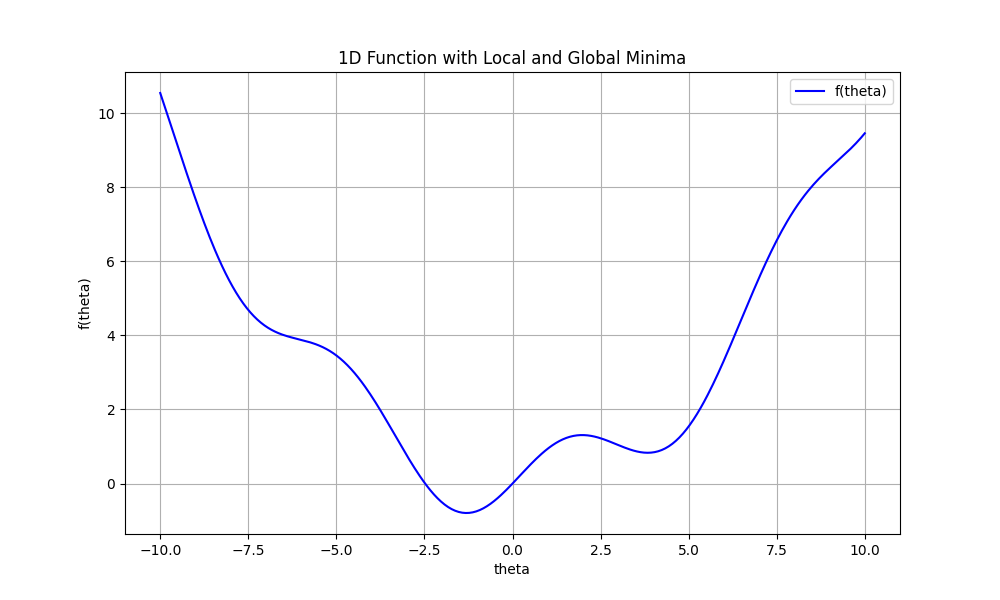

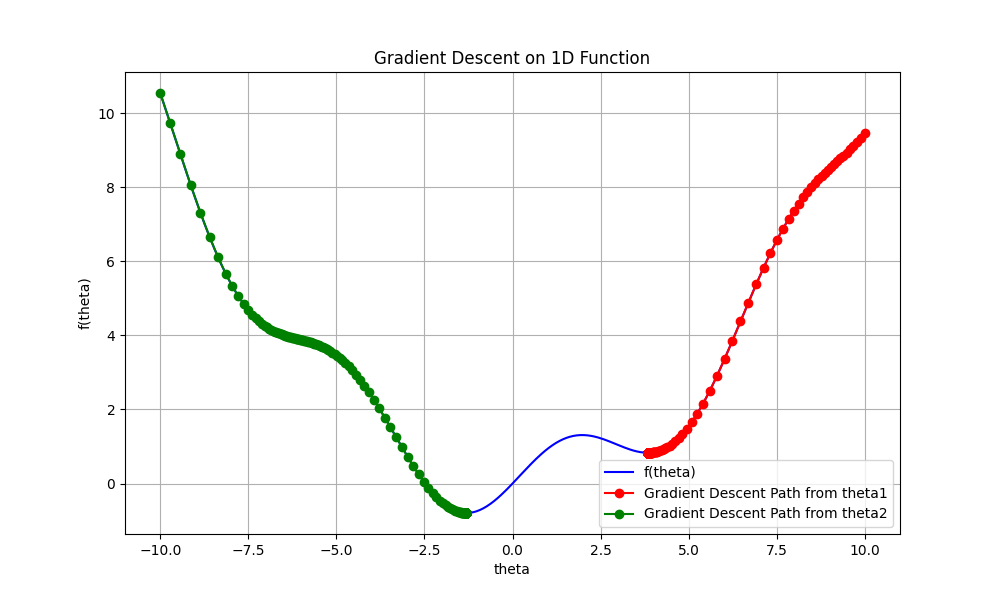

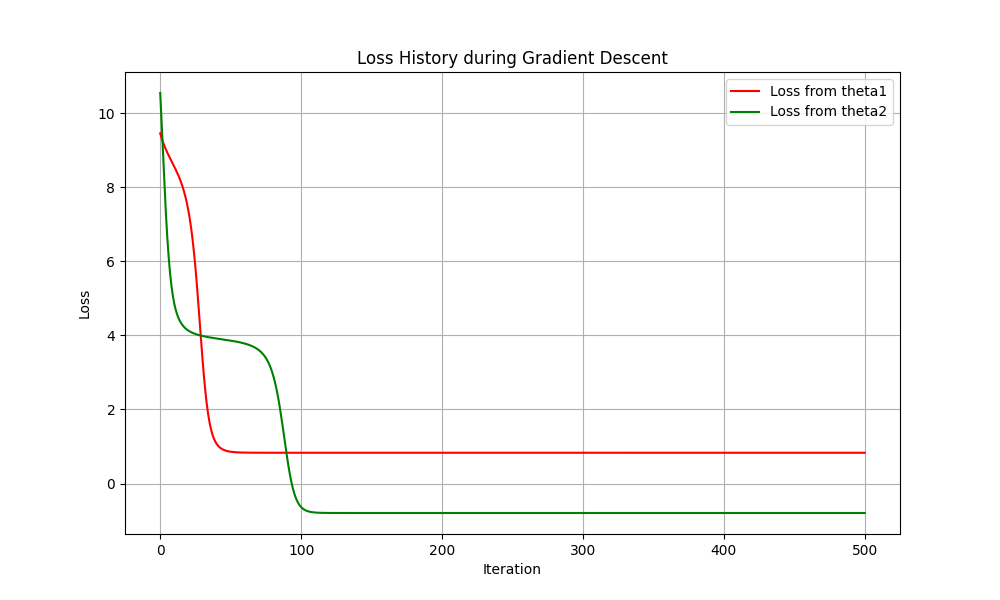

In [66]:
## Example of 1D gradient decent with local and global minima

# lets define a 1D function with a local and global minima

import numpy as np 
import matplotlib.pyplot as plt

theta_vec = np.linspace(-10, 10, 400)# create a vector of theta values from -10 to 10

def f(theta):
    return np.sin(theta) + 0.1 * theta**2  # a function with a local and global minima
plt.figure(figsize=(10, 6))
plt.plot(theta_vec, f(theta_vec), label='f(theta)', color='blue')
plt.title('1D Function with Local and Global Minima')
plt.xlabel('theta')
plt.ylabel('f(theta)')
plt.grid()
plt.legend()
plt.show()

# Now we will perform gradient descent on this function starting from a random point
theta1 = 10 # random starting point
theta2 = -10 # random starting point
# now we perform gradient descent starting from theta1 and theta2 and we will see how it converges to the local and global minima respectively
learning_rate = 0.1
num_iterations = 500
theta1_history = [theta1]
theta2_history = [theta2]
loss1_history = [f(theta1)]
loss2_history = [f(theta2)]
for i in range(num_iterations):
    # Calculate the gradient (numerical approximation)
    epsilon = 1e-5
    grad1 = (f(theta1 + epsilon) - f(theta1 - epsilon)) / (2 * epsilon)
    grad2 = (f(theta2 + epsilon) - f(theta2 - epsilon)) / (2 * epsilon)
    
    # Update theta using gradient descent
    theta1 -= learning_rate * grad1
    theta2 -= learning_rate * grad2
    
    # Store history for visualization
    theta1_history.append(theta1)
    theta2_history.append(theta2)
    loss1_history.append(f(theta1))
    loss2_history.append(f(theta2))
# Plot the function and the path taken by gradient descent
plt.figure(figsize=(10, 6))
plt.plot(theta_vec, f(theta_vec), label='f(theta)', color='blue')
plt.plot(theta1_history, loss1_history, marker='o', color='red', label='Gradient Descent Path from theta1')
plt.plot(theta2_history, loss2_history, marker='o', color='green', label='Gradient Descent Path from theta2')
plt.title('Gradient Descent on 1D Function')
plt.xlabel('theta')
plt.ylabel('f(theta)')
plt.grid()
plt.legend()
plt.show()


# now plot the loss history to see how it converges
plt.figure(figsize=(10, 6))
plt.plot(loss1_history, label='Loss from theta1', color='red')
plt.plot(loss2_history, label='Loss from theta2', color='green')
plt.title('Loss History during Gradient Descent')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid()
plt.legend()
plt.show()




## Backpropagation
What we missed for now is how to find the direction in which we should make the step. In the previous section we phrased it "In the direction where the objective minimizes". To find this direction we take the first partial derivative of the objective function $R(\theta)$

$$
\nabla R(\theta) = \frac{\delta R(\theta)}{\delta \theta}|_{\theta = \theta_m}
$$

$\theta = \theta_m$ means we evaluate the derivative at the current guess $\theta_m$. Then the derivative will give us the direction where $R(\theta )$ increases most rapidly and we move theta then by a step controlled by the learning rate in the opposite direction. If we do this procedure of calculating derivatives and updating theta, the gradients can become 0 which indicates that we reached a minimum.

Recalling our initial minimization goal

$$
min_{\omega_K|_1^K, \beta} \frac{1}{2} \Sigma_{i=1}^n (y_i - f(x_i))^2
$$
we can write 
$$
R(\theta) \frac{1}{2} \Sigma_{i=1}^n (y_i - f(x_i))^2
$$

where $\theta$ contains all weight and bias terms of the model$

Since R is a sum over all our labeled observations we can calculate the gradients for each observation and label individually and sum up the total loss afterwards.

$$
R_i = \frac{1}{2} (y_i - \beta_0 - \Sigma_{k=1}^K \beta_k g(\omega_{k0}+ \Sigma_{j=1}^p \omega_{kj}))^2
$$

To simplify the term we substitute the second therm with $z_k = \omega_{k0}+ \Sigma_{j=1}^p \omega_{kj}$ and then take the partial derivative with respect to $\beta_k$

$$
\frac{\delta R(\theta_i)}{\delta \beta_k} = -(y_i - f_\theta(x_i))g(z_{ik})
$$

and with respect to $\omega_{kj}$

$$
\frac{\delta R(\theta_i)}{\delta \omega_{kj}} = -(y_i - f_\theta(x_i)) \beta_k g'(z_{ik})x_{ij}.
$$

Both terms contain the residual $-(y_i - f_\theta(x_i))$. The upper term attributes a part of the residual to the model parameters of the hidden units with the value of g(z_{ik}) and the lower term shows that a part of the residuals is attributed to the input j via hidden unit k. Therefore we propagate the errors back through the model and assign a fraction of the residual to each unit of the model. This process is called backpropagation and the working horse for modern AI. Calculating the gradients and performing the updates requires a solid implementation of the algorithm and tight bookkeeping of the values. Therefore it is recommend to stick to modern deep learning libraries which take care of it.



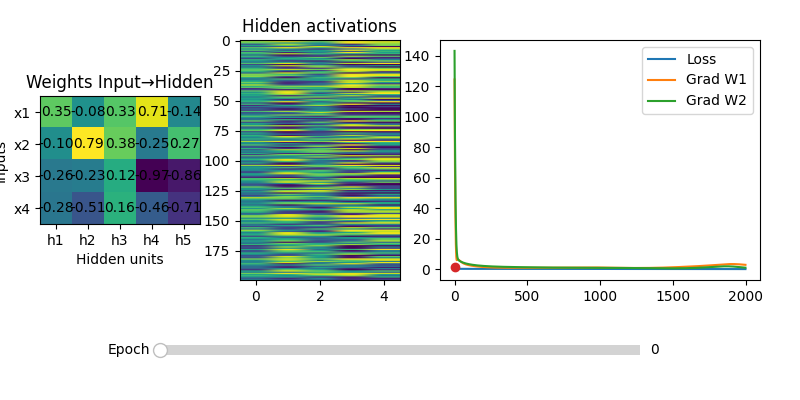

C:\Users\Johannes\AppData\Local\Temp\ipykernel_21276\491736344.py:208: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grid[j,i]=z


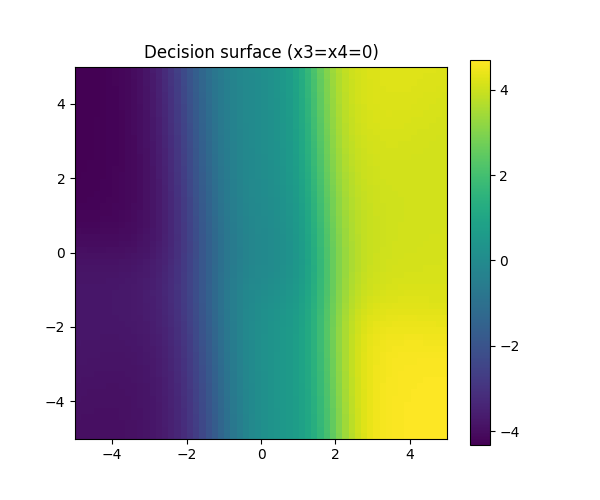

Test MSE: 1354.325746104942


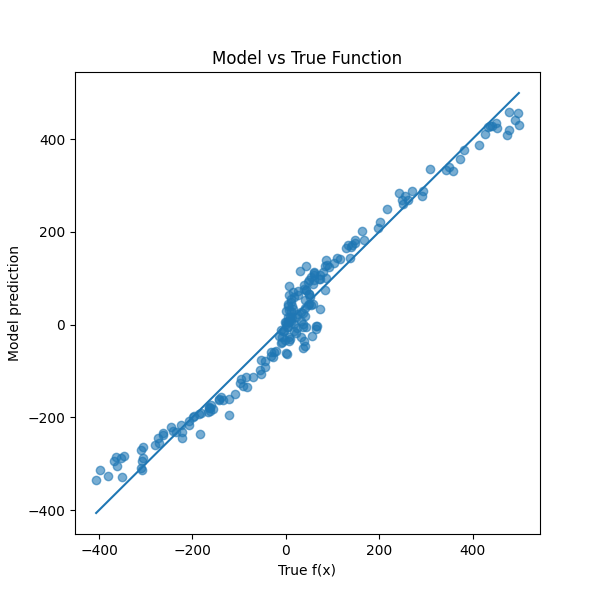

In [67]:
# =========================
# Backprop Demo 
# =========================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import matplotlib
matplotlib.use("TkAgg")   # oder PyQt5Agg
%matplotlib widget
np.random.seed(42)

# -----------------
# Architektur
# -----------------
input_neurons = 4
hidden_neurons = 5
output_neurons = 1

# -----------------
# Aktivierungen
# -----------------
def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_deriv(a):
    return a*(1-a)

def tanh(x):
    return np.tanh(x)

def tanh_deriv(a):
    return 1 - a**2

# -----------------
# Xavier Init
# -----------------
W1 = np.random.randn(input_neurons, hidden_neurons)/np.sqrt(input_neurons)
b1 = np.zeros(hidden_neurons)
W2 = np.random.randn(hidden_neurons, output_neurons)/np.sqrt(hidden_neurons)
b2 = np.zeros(output_neurons)

def draw_weight_labels(ax, W, prefix_x="x", prefix_h="h"):
    ax.clear()

    im = ax.imshow(W)

    # Ticks setzen
    ax.set_xticks(np.arange(W.shape[1]))
    ax.set_yticks(np.arange(W.shape[0]))

    ax.set_xticklabels([f"{prefix_h}{j+1}" for j in range(W.shape[1])])
    ax.set_yticklabels([f"{prefix_x}{i+1}" for i in range(W.shape[0])])

    ax.set_xlabel("Hidden units")
    ax.set_ylabel("Inputs")

    # Text in jede Zelle
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            ax.text(j, i,
                    f"{W[i,j]:.2f}",
                    ha="center", va="center")

    return im

# -----------------
# Datensatz
# -----------------

def true_function(X):
    Y = 4*X[:,0]**3 + 3*X[:,1]**2 - .1*X[:,2] + 0.1*X[:,3]
    return Y.reshape(-1,1)
def generate_dataset(n):
    X = np.random.rand(n, input_neurons)*10 - 5
    Y = true_function(X)
    return X, Y

X_train, Y_train = generate_dataset(200)

X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0)
X_train_n = (X_train - X_mean) / X_std
Y_mean, Y_std = Y_train.mean(), Y_train.std()
Y_train_n = (Y_train - Y_mean)/Y_std
# -----------------
# Forward / Loss
# -----------------
def forward(X, params):
    W1,b1,W2,b2 = params
    Z1 = X@W1 + b1
    A1 = tanh(Z1)
    Z2 = A1@W2 + b2  # linear output
    return Z1,A1,Z2

def loss_fn(y, yhat):
    return np.mean((y-yhat)**2)

# -----------------
# Train Step
# -----------------
def train_step(X,y,params,lr):
    W1,b1,W2,b2 = params

    Z1,A1,Z2 = forward(X,params)
    loss = loss_fn(y,Z2)

    dZ2 = (Z2-y)
    dW2 = A1.T@dZ2
    db2 = dZ2.sum(axis=0)

    dZ1 = (dZ2@W2.T)*tanh_deriv(A1)
    dW1 = X.T@dZ1
    db1 = dZ1.sum(axis=0)

    gnorm1 = np.linalg.norm(dW1)
    gnorm2 = np.linalg.norm(dW2)

    W1 -= lr*dW1
    b1 -= lr*db1
    W2 -= lr*dW2
    b2 -= lr*db2

    return loss,(W1,b1,W2,b2),A1,gnorm1,gnorm2

# -----------------
# Training
# -----------------
params=(W1,b1,W2,b2)
epochs=2000
lr=1E-3

hist={"loss":[],"A1":[],"W1":[],"W2":[],"g1":[],"g2":[]}

for e in range(epochs):
    loss, params, A1, g1, g2 = train_step(X_train_n, Y_train_n, params, lr)

    hist["loss"].append(loss)
    hist["A1"].append(A1.copy())
    hist["W1"].append(params[0].copy())
    hist["W2"].append(params[2].copy())
    hist["g1"].append(g1)
    hist["g2"].append(g2)

   # print(f"Epoch {e+1}/{epochs}  Loss={loss:.4f}")

# -----------------
# Arrays
# -----------------
W1_hist=np.array(hist["W1"])
W2_hist=np.array(hist["W2"])
A1_hist=np.array(hist["A1"])
loss_hist=np.array(hist["loss"])
g1=np.array(hist["g1"])
g2=np.array(hist["g2"])

# -----------------
# Interaktive Visualisierung
# -----------------
fig=plt.figure(figsize=(8,4))

ax_w1=plt.axes([0.05,0.3,0.2,0.6])
ax_act=plt.axes([0.3,0.3,0.2,0.6])
ax_loss=plt.axes([0.55,0.3,0.4,0.6])
ax_slider=plt.axes([0.2,0.1,0.6,0.05])

epoch0=0

im_w1 = draw_weight_labels(ax_w1, W1_hist[epoch0])
ax_w1.set_title("Weights Input→Hidden")

im_act=ax_act.imshow(A1_hist[epoch0],aspect="auto")
ax_act.set_title("Hidden activations")

ax_loss.plot(loss_hist,label="Loss")
ax_loss.plot(g1,label="Grad W1")
ax_loss.plot(g2,label="Grad W2")
marker,=ax_loss.plot(epoch0,loss_hist[epoch0],marker="o")
ax_loss.legend()

slider=Slider(ax_slider,"Epoch",0,epochs-1,valinit=0,valstep=1)

def update(val):
    e = int(slider.val)

    draw_weight_labels(ax_w1, W1_hist[e])
    im_act.set_data(A1_hist[e])
    marker.set_data([e],[loss_hist[e]])

    fig.canvas.draw_idle()

slider.on_changed(update)
plt.show()

# -----------------
# Decision Surface (2D Slice)
# -----------------
def decision_surface(params):
    W1,b1,W2,b2=params
    xs=np.linspace(-5,5,60)
    ys=np.linspace(-5,5,60)
    grid=np.zeros((60,60))

    for i,x in enumerate(xs):
        for j,y in enumerate(ys):
            inp=np.array([[x,y,0,0]])
            _,_,z=forward(inp,params)
            grid[j,i]=z

    plt.figure(figsize=(6,5))
    plt.imshow(grid,extent=[-5,5,-5,5],origin="lower")
    plt.title("Decision surface (x3=x4=0)")
    plt.colorbar()
    plt.show()

decision_surface(params)


def model_function(X, params, Y_mean, Y_std):
    _, _, y_pred_norm = forward(X, params)
    return y_pred_norm * Y_std + Y_mean




# Target-Standardisierung (wichtig)
Y_mean, Y_std = Y_train.mean(), Y_train.std()
Y_train_n = (Y_train - Y_mean)/Y_std


Y_true = true_function(X_train)
Y_pred = model_function((X_train - X_mean)/X_std, params, Y_mean, Y_std)

mse = np.mean((Y_true - Y_pred)**2)
print("Test MSE:", mse)

plt.figure(figsize=(6,6))
plt.scatter(Y_true, Y_pred, alpha=0.6)
plt.plot([Y_true.min(), Y_true.max()],
         [Y_true.min(), Y_true.max()])
plt.xlabel("True f(x)")
plt.ylabel("Model prediction")
plt.title("Model vs True Function")
plt.show()


## Regularization and Stochastic Gradient Descent

### Stochastic gradient descent and mini batch gradient descent

**Gradient descent** takes usually many steps until it converges towards a local minimum (See the first example on gradient descent on the 1D function). This steps are also called epochs in the deep learning literature. As we saw in the previous formula for the calculation of backpropagation we need to perform the forward path over all i=1 ... n observations to obtain $f\theta_i(x_i)$ to calculate our objective $(x_i - f\theta_i(x_i) )$ which we want to minimize over all our samples n. Therefore for the full gradient descent or batch gradient descent, which uses the full batch of data, we need to have to carry out a full forward path of all n samples with the current model parameters $\theta_i$, then calculate exact one set of gradients using backpropagation to finally update the model parameters according to their gradients. 

This is computational demanding and thus a less accurate (higher variance) variant of the batch gradient descent, is the **stochastic gradient descent** approach. Here randomly normal distributed one sample out of n is drawn without replacement per weight update, feed forward through the model, gradients are calculated and the model parameters are updated. This is repeated until all samples are drawn for this epoch before the next epoch starts. For a dataset of size $n$ this means $n$ updates of the model parameters $\theta$ per epoch, leading to many but noisy updates, which has one interesting property. Due to the noise this approach is capable to escape shallow local minima or saddle points in the optimization function, which makes convergence less smooth but allows to escape local minima due to the noise introduction. 

The most common resent approach used in training modern deep neural network is the **mini batch gradient descent approach**. It uses a small batch $B$ out of the n samples to calculate the gradients and perform a update of the model parameters. For all samples in $B$ the observations are forwarded through the model, the batch loss is calculated and the gradients are calculated and finally the model parameters are updated. The split of the full dataset into mini batches has also an advantage with respect to computational speed as the smaller batches allow to be stored on the cache memory of the CPU or on the memory of a graphics card to speed up the training procedure. 

### Overview table

| Method | Data Used per Update | Updates per Epoch | Gradient Variance | Computational Speed | Typical Use |
|--------|---------------------|------------------|------------------|--------------------|-------------|
| Batch GD | All $N$ samples | $1$ | Very low | Slow | Small datasets, theoretical analysis |
| SGD | $1$ sample | $N$ | Very high | Fast | Online learning, noisy optimization |
| Mini-Batch GD | $B$ samples | $N/B$ | Medium | Fast and stable | Default in deep learning |

###  Key Takeaways
 - Backpropagation computes **layer-by-layer gradients** using the chain rule 
 - Gradient descent variants differ only in **how much data is used per update** 
 - Mini-batch GD is the standard in practice 
 - SGD noise can improve generalization and exploration of the loss landscape

## Regularization

As we learned in chapter 6 by introduction of regularization we can reduce overfitting of models by shrinking the model weights $\theta$ and thus discouraging over complex models. This concept can be also used in deep neural networks by expanding the loss function with a regularization term that contains the magnitude of the model parameters. 
$$
R(\theta, \lambda) \frac{1}{2} \Sigma_{i=1}^n (y_i - f(x_i))^2 + \lambda \Sigma_{j} \theta_j^2
$$
with $\lambda$ is a controllable hyperparameter set to a small value and can be optimized based on a validation set.

### Gradient Effect
 The gradient update becomes
  $$ 
  \theta \leftarrow \theta - \eta \left( \nabla_\theta \mathcal{L} + 2\lambda \theta \right) 
  $$
This is often referred to as **weight decay** in deep learning.

### Summary on L1 and L2 normalization

| Regularization | Penalty | Effect on Weights | Typical Use | |---|---|---|---| | L2 | $ \sum \theta_j^2 $ | Shrinks weights smoothly | Default in neural networks | | L1 | $ \sum |\theta_j| $ | Produces sparse weights | Feature selection |

## Further regularization methods
Regularization is not limited to adding penalty terms such as L1 or L2 to the loss function. In modern neural networks, **training procedures themselves** often act as regularizers by limiting effective model capacity or introducing stochasticity into the optimization process. The following regularization methods namely dropout, early stopping, and mini-batch SGD (as introduced earlier) can all be understood through the **bias–variance trade-off** and their effect on the optimization landscape.

# 1. Dropout
Dropout randomly removes (sets to zero) a subset of hidden units during each training iteration. This means the network effectively trains a **different subnetwork** on every forward pass. Let the activation vector in layer $l$ be $a^{(l)}$. We sample a mask
 $$
  m^{(l)} \sim \text{Bernoulli}(p) 
 $$
and compute 
$$ 
\tilde{a}^{(l)} = m^{(l)} \odot a^{(l)}
$$
where $p$ is the probability of **keeping** a neuron active. By randomly deactivating neurons, dropout prevents the network from relying too heavily on any single feature or pathway. Instead of learning a single complex model, the network learns an **ensemble of many simpler models** that share parameters. At test time, we use the full network but scale activations by $p$, which approximates averaging predictions across these subnetworks.  This slightly increases bias (model is noisier during training) but strongly reduces variance, which improves generalization. Dropout is particularly effective in large networks where overfitting arises from highly co-adapted features.

# 2. Early Stopping
Early stopping monitors performance on a validation set during training and halts optimization when validation error begins to increase.  During gradient descent overfitting happens due to the following reasons:
 1. Early iterations capture **large-scale structure** in the data 
 2. Later iterations begin fitting **noise and idiosyncrasies** 
 This produces the classic behavior:
 - Training error decreases monotonically
 - Validation error decreases, then increases Stopping at the minimum validation error selects a model with better generalization.
Early stopping can be interpreted as constraining the magnitude of parameters. For linear models, it can be shown that **early stopping behaves similarly to L2 regularization**, because limited optimization time prevents parameters from growing large. This prevents variance from growing excessively and keeps model in a region of moderate complexity.

# 3. Mini-Batch SGD as Implicit Regularization
In mini-batch gradient descent, the gradient is computed from a random subset of data: 
$$
g_B = \frac{1}{B} \sum_{i \in B} \nabla_\theta \mathcal{L}(x_i,\theta) 
$$
This is a **noisy estimate** of the true gradient:
$$ 
g_B = g + \epsilon 
$$ 
where $g$ is the full-dataset gradient and $\epsilon$ is stochastic noise
Modern deep networks have highly non-convex loss surfaces with:
- Sharp minima (narrow valleys)
- Flat minima (wide basins)
The noise introduced by SGD tends to push parameters away from sharp minima and toward flatter regions, which are associated with better generalization. Therefore mini-batch SGD acts similarly to adding noise to the optimization dynamics, which limits overfitting, prevents overly precise fitting of training data and improves robustness of the model. This is why SGD is often described as **implicit regularization** — the regularization arises from the algorithm itself rather than an explicit penalty term.

# Key Takeaway
 Regularization in deep learning is not just about modifying the loss function and adding a L1 or L2 regularization. The **training dynamics themselves** play a crucial role in controlling model complexity and generalization performance.



## Additional Regularization Techniques (Deep Learning)

![Regularization Taxonomy](./Images\RegularizationTechniques.png)

- **Data Augmentation** – Increases the effective training set via label-preserving transformations, improving invariance and reducing overfitting.  
- **Dropout Variants (e.g., SpatialDropout, DropConnect)** – Extend standard dropout by randomly removing entire feature maps or weight connections during training.  
- **Batch Normalization (as a regularizer)** – The stochasticity of batch statistics introduces noise that often improves generalization in addition to stabilizing optimization.  
- **Label Smoothing** – Replaces hard one-hot targets with slightly smoothed distributions to prevent over-confident predictions.  
- **Stochastic Depth / Layer Drop** – Randomly skips whole layers (often residual blocks) during training, acting like an ensemble of shallower networks.  
- **Mixup / CutMix** – Generates virtual training examples by combining inputs and labels, encouraging smoother decision boundaries.  
- **Weight Sharing / Parameter Tying** – Reduces effective model complexity by constraining parameters to be shared across structures.  
- **Spectral Normalization** – Controls the Lipschitz constant of layers by normalizing the largest singular value of weight matrices.  
- **Sharpness-Aware Minimization (SAM)** – Optimizes parameters toward flat minima that are more robust to perturbations.  
- **Knowledge Distillation** – Trains a smaller student model on soft targets from a teacher model to transfer inductive biases.  


## Vanishing and exploding gradients
One common issue in the training procedure of models is the vanishing and exploding gradient problem, which basically stops the model to converge. 

### Vanishing gradients
Vanishing gradients describe a numerical phenomena when training deep models with many layers, where the derivative of the activation function becomes infinitesimal small close to 0. Recalling the calculation of the derivative w.r.t. $\omega_kj$ 
$$
\frac{\delta R(\theta_i)}{\delta \omega_{kj}} = -(y_i - f_\theta(x_i)) \beta_k g'(z_{ik})x_{ij}.
$$

if the derivative of g' comes close to 0 the residual $y_i - f_\theta(x_i)$ will become 0 and during backpropagation the gradients which are flowing to the lower layers will become exponentially lower and vanish. A typical case for having a g' close to zero is if the sigmoid or tanh activation function is used and gets big values as input. The problem of vanishing gradients is especially present when training deep models with many layers. By introduction of the Relu activation as a activation function which prevents that the derivative becomes close to 0 the training of deeper models gets more stable. A second approach to prevent vanishing gradients is the introduction of skip connections which we will introduce later.



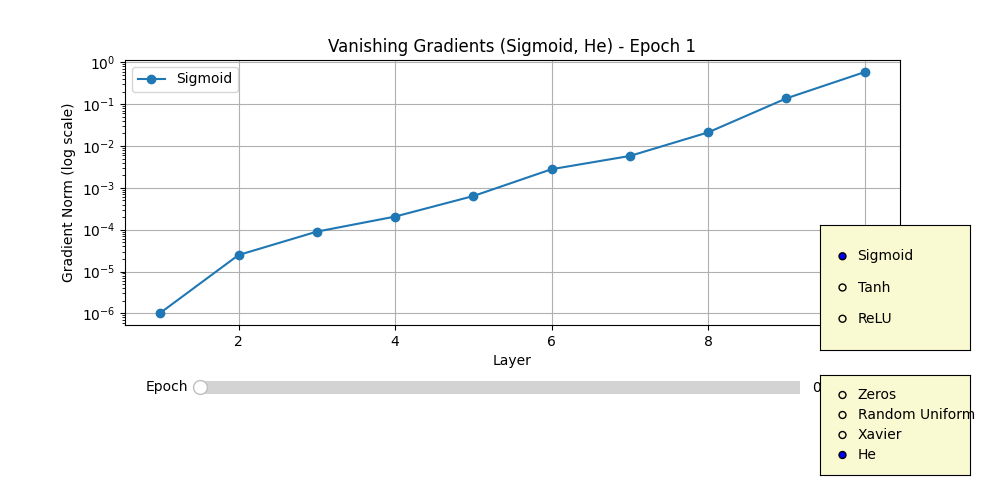

In [68]:
# =========================
# Interactive Vanishing Gradient Demo (Full Version)
# =========================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, RadioButtons

np.random.seed(42)

# -----------------------------
# Network architecture
# -----------------------------
n_layers = 10
n_hidden = 5
input_size = 1
output_size = 1

# -----------------------------
# Activation functions
# -----------------------------
def sigmoid(x): return 1/(1+np.exp(-x))
def sigmoid_deriv(a): return a*(1-a)

def tanh(x): return np.tanh(x)
def tanh_deriv(a): return 1 - a**2

def relu(x): return np.maximum(0,x)
def relu_deriv(a): return (a>0).astype(float)

def leaky_relu(x, alpha=0.01): return np.where(x>0, x, alpha*x)
def leaky_relu_deriv(a, alpha=0.01): return np.where(a>0, 1, alpha)

activations_dict = {
    "Sigmoid": (sigmoid, sigmoid_deriv),
    "Tanh": (tanh, tanh_deriv),
    "ReLU": (leaky_relu, leaky_relu_deriv),
   # "Leaky ReLU": (leaky_relu, leaky_relu_deriv) Relu scheint immer 0 zu werden, daher nur Leaky ReLU
}

# -----------------------------
# Initializer function
# -----------------------------
def init_weights(method):
    weights = []
    biases = []
    for i in range(n_layers):
        n_in = input_size if i==0 else n_hidden
        n_out = n_hidden if i<n_layers-1 else output_size
        if method=="Zeros":
            W = np.zeros((n_in, n_out))
        elif method=="Random Uniform":
            W = np.random.uniform(-0.5,0.5,(n_in,n_out))
        elif method=="Xavier":
            W = np.random.randn(n_in,n_out) * np.sqrt(1/n_in)
        elif method=="He":
            W = np.random.randn(n_in,n_out) * np.sqrt(2/n_in)
        b = np.zeros(n_out)
        weights.append(W)
        biases.append(b)
    return weights, biases

init_methods = ["Zeros", "Random Uniform", "Xavier", "He"]

# -----------------------------
# Inputs / Targets
# -----------------------------
x_vals = np.linspace(-3,3,5).reshape(-1,1)
target_vals = np.zeros_like(x_vals)

# -----------------------------
# Training params
# -----------------------------
lr = 0.1
epochs = 100

# -----------------------------
# Gradient computation
# -----------------------------
def compute_gradients(weights, biases, act_func, act_deriv):
    grad_history = []

    for ep in range(epochs):
        # ----- Forward -----
        a = x_vals[:1]   # nur ein Sample für klare Kette
        activations_list = []

        for W, b in zip(weights, biases):
            z = a @ W + b
            a = act_func(z)
            activations_list.append(a)

        # ----- Backward (nur propagieren, NICHT updaten) -----
        delta = np.ones_like(a)   # Startgradient = 1
        grad_norms = []

        for i in reversed(range(n_layers)):
            a_i = activations_list[i]
            delta = delta * act_deriv(a_i)
            delta = delta @ weights[i].T   # Jacobian-Weitergabe
            grad_norms.append(np.linalg.norm(delta))

        grad_history.append(grad_norms[::-1])

    return np.array(grad_history)
# -----------------------------
# Initialize defaults
# -----------------------------
current_activation = "Sigmoid"
current_init = "He"
weights_base, biases_base = init_weights(current_init)
act_func, act_deriv = activations_dict[current_activation]
grad_histories = {current_activation: compute_gradients(weights_base, biases_base, act_func, act_deriv)}

# -----------------------------
# Plot setup
# -----------------------------
fig, ax = plt.subplots(figsize=(10,5))
plt.subplots_adjust(bottom=0.35)

line, = ax.plot(range(1,n_layers+1), grad_histories[current_activation][0],
                marker='o', label=current_activation)
ax.set_yscale('log')
ax.set_xlabel("Layer")
ax.set_ylabel("Gradient Norm (log scale)")
ax.set_title(f"Vanishing Gradients ({current_activation}, {current_init}) - Epoch 1")
ax.grid(True)
ax.legend()

# Slider
ax_slider = plt.axes([0.2,0.2,0.6,0.05])
slider = Slider(ax_slider, "Epoch", 0, epochs-1, valinit=0, valstep=1)

# Activation RadioButtons
ax_radio = plt.axes([0.82,0.3,0.15,0.25], facecolor='lightgoldenrodyellow')
radio = RadioButtons(ax_radio, list(activations_dict.keys()), active=0)

# Initializer RadioButtons
ax_init = plt.axes([0.82,0.05,0.15,0.2], facecolor='lightgoldenrodyellow')
radio_init = RadioButtons(ax_init, init_methods, active=3)

# -----------------------------
# Update functions
# -----------------------------
def update_epoch(val):
    e = int(slider.val)
    line.set_ydata(grad_histories[current_activation][e])
    ax.set_title(f"Vanishing Gradients ({current_activation}, {current_init}) - Epoch {e+1}")
    fig.canvas.draw_idle()

def update_activation(label):
    global current_activation, act_func, act_deriv, grad_histories
    current_activation = label
    act_func, act_deriv = activations_dict[current_activation]
    # Recompute gradients if not already
    if current_activation not in grad_histories:
        grad_histories[current_activation] = compute_gradients(weights_base, biases_base, act_func, act_deriv)
    e = int(slider.val)
    line.set_ydata(grad_histories[current_activation][e])
    line.set_label(current_activation)
    ax.legend()
    ax.set_title(f"Vanishing Gradients ({current_activation}, {current_init}) - Epoch {e+1}")
    fig.canvas.draw_idle()

def update_initializer(label):
    global current_init, weights_base, biases_base, grad_histories
    current_init = label
    weights_base, biases_base = init_weights(current_init)
    # Clear cached gradients
    grad_histories = {}
    act_func, act_deriv = activations_dict[current_activation]
    grad_histories[current_activation] = compute_gradients(weights_base, biases_base, act_func, act_deriv)
    e = int(slider.val)
    line.set_ydata(grad_histories[current_activation][e])
    ax.set_title(f"Vanishing Gradients ({current_activation}, {current_init}) - Epoch {e+1}")
    fig.canvas.draw_idle()

slider.on_changed(update_epoch)
radio.on_clicked(update_activation)
radio_init.on_clicked(update_initializer)

plt.show()